In [10]:
# =============================================================================
# MIMIC-Extract XGBoost Baseline for In-Hospital Mortality Prediction
#
# Author: Critical & Independent Scientific Expert
#
# Description:
# This notebook establishes a baseline machine learning model using XGBoost
# to predict in-hospital mortality. It uses the pre-processed, hourly
# time-series data from the 'all_hourly_data.h5' file generated by the
# MIMIC-Extract pipeline.
#
# Methodology:
# 1.  Load patient outcomes and time-series data (vitals & labs).
# 2.  Engineer features by aggregating the first 24 hours of data for each
#     patient into a single feature vector (mean and std dev).
# 3.  Split the data into training and testing sets.
# 4.  Train an XGBoost classifier.
# 5.  Evaluate the model using AUROC and other standard metrics.
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import subprocess
import xgboost as xgb

print(f"Libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")


Libraries imported successfully.
Pandas version: 0.24.2


In [11]:
# =============================================================================
# Section 1: Experiment Configuration
# --- All user-adjustable parameters are in this cell ---
# =============================================================================

# -- File Path --
# Update this path to your MIMIC-Extract HDF5 file.
HDF_FILE_PATH = '../data/raw/all_hourly_data.h5'

# -- Sampling for Development --
# Set to an integer (e.g., 100) to use a small random sample of patients for
# fast testing. Set to None to use the entire dataset.
N_SAMPLES_TO_USE = None

# -- Prediction Target --
# This is the outcome variable we want to predict.
# Options from the 'patients' table include: 'mort_icu', 'mort_hosp'.
TARGET_VARIABLE = 'mort_hosp'

# -- Model Hyperparameters --
# Simplified parameters to avoid XGBoost 1.5.2 compatibility issues
XGB_PARAMS = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'random_state': 42 # For reproducibility
}

In [12]:
# COMPLETE DATA LOADING AND FIXING SOLUTION
print("=== LOADING DATA WITH PROPER MULTIINDEX HANDLING ===")

# First, load the data properly
if not os.path.exists(HDF_FILE_PATH):
    print(f"--- CRITICAL ERROR: File not found at '{HDF_FILE_PATH}' ---")
else:
    print("Loading data from HDF5 store...")
    
    with pd.HDFStore(HDF_FILE_PATH, 'r') as store:
        # Load patient data
        print("Loading patient data...")
        df_patients = store.select('/patients')
        print(f"✓ Patients loaded: {df_patients.shape}")
        
        # Load vitals_labs_mean (preferred) or vitals_labs (fallback)
        if '/vitals_labs_mean' in store.keys():
            print("Loading vitals_labs_mean (pre-aggregated hourly means)...")
            df_ts = store.select('/vitals_labs_mean')
            print(f"✓ vitals_labs_mean loaded: {df_ts.shape}")
            
            # Handle MultiIndex
            if isinstance(df_ts.columns, pd.MultiIndex):
                print(f"✓ Found MultiIndex with {df_ts.columns.nlevels} levels")
                # Extract just feature names (first level)
                df_ts.columns = [col[0] for col in df_ts.columns]
                print("✓ Extracted feature names from MultiIndex")
            
        elif '/vitals_labs' in store.keys():
            print("Loading full vitals_labs table...")
            df_ts = store.select('/vitals_labs')
            print(f"✓ vitals_labs loaded: {df_ts.shape}")
            print(f"Column type: {type(df_ts.columns)}")
            
            # Handle MultiIndex - select only 'mean' columns
            if isinstance(df_ts.columns, pd.MultiIndex):
                print(f"✓ Found MultiIndex with {df_ts.columns.nlevels} levels")
                mean_cols = df_ts.columns[df_ts.columns.get_level_values(1) == 'mean']
                df_ts = df_ts[mean_cols]
                df_ts.columns = [col[0] for col in df_ts.columns]
                print(f"✓ Selected {len(mean_cols)} 'mean' columns")
            else:
                print("⚠️  Expected MultiIndex but found flat columns")
                # This means the MultiIndex was already flattened improperly
                print("Attempting to reconstruct from flat columns...")
                
                # Check if we have the 3:1 pattern (count/mean/std)
                unique_features = []
                for col in df_ts.columns:
                    col_str = str(col)
                    base_name = col_str.split('_')[0] if '_' in col_str and col_str.split('_')[-1].isdigit() else col_str
                    if base_name not in unique_features:
                        unique_features.append(base_name)
                
                ratio = len(df_ts.columns) / len(unique_features)
                print(f"Detected {len(unique_features)} unique features, ratio: {ratio:.1f}")
                
                if abs(ratio - 3.0) < 0.1:
                    print("✓ Detected count/mean/std pattern - reconstructing...")
                    
                    # Group columns by base feature name
                    feature_groups = {}
                    for col in df_ts.columns:
                        col_str = str(col)
                        if '_' in col_str and col_str.split('_')[-1].isdigit():
                            parts = col_str.split('_')
                            base_name = '_'.join(parts[:-1])
                            suffix_num = int(parts[-1])
                        else:
                            base_name = col_str
                            suffix_num = 0
                        
                        if base_name not in feature_groups:
                            feature_groups[base_name] = []
                        feature_groups[base_name].append((suffix_num, col))
                    
                    # Extract 'mean' columns (typically suffix 1, but could be 0 if only one)
                    mean_columns = []
                    mean_names = []
                    
                    for feature_name, cols in feature_groups.items():
                        cols.sort()  # Sort by suffix number
                        if len(cols) >= 2:
                            # Assume: 0=count, 1=mean, 2=std
                            mean_col = cols[1][1]  # Take second column (index 1)
                        else:
                            # Only one column, assume it's the mean
                            mean_col = cols[0][1]
                        
                        mean_columns.append(mean_col)
                        mean_names.append(feature_name)
                    
                    # Create new dataframe with only mean columns
                    df_ts = df_ts[mean_columns].copy()
                    df_ts.columns = mean_names
                    
                    print(f"✓ Reconstructed {len(mean_columns)} mean columns")
                    print(f"Sample features: {mean_names[:10]}")
                
        else:
            print("⚠️  No vitals_labs table found!")
            df_ts = None
        
        print(f"\nFinal data shapes:")
        print(f"  Patients: {df_patients.shape}")
        if df_ts is not None:
            print(f"  Time-series: {df_ts.shape}")
            print(f"  Sample columns: {df_ts.columns[:10].tolist()}")
            
            # Check for duplicates
            if df_ts.columns.duplicated().any():
                print(f"⚠️  Found {df_ts.columns.duplicated().sum()} duplicate columns")
            else:
                print("✓ No duplicate column names")
        
        # Apply sampling if needed
        if N_SAMPLES_TO_USE is not None and df_ts is not None:
            print(f"\n--- APPLYING SAMPLING ({N_SAMPLES_TO_USE} patients) ---")
            all_patient_ids = df_patients.index.get_level_values('icustay_id').unique()
            np.random.seed(42)
            sampled_ids = np.random.choice(all_patient_ids, N_SAMPLES_TO_USE, replace=False)
            
            df_patients = df_patients[df_patients.index.get_level_values('icustay_id').isin(sampled_ids)]
            df_ts = df_ts[df_ts.index.get_level_values('icustay_id').isin(sampled_ids)]
            
            print(f"✓ Sampled data shapes:")
            print(f"  Patients: {df_patients.shape}")
            print(f"  Time-series: {df_ts.shape}")

print("✓ Data loading complete!")


=== LOADING DATA WITH PROPER MULTIINDEX HANDLING ===
Loading data from HDF5 store...
Loading patient data...
✓ Patients loaded: (34472, 28)
Loading vitals_labs_mean (pre-aggregated hourly means)...
✓ vitals_labs_mean loaded: (2200954, 104)
✓ Found MultiIndex with 2 levels
✓ Extracted feature names from MultiIndex

Final data shapes:
  Patients: (34472, 28)
  Time-series: (2200954, 104)
  Sample columns: ['alanine aminotransferase', 'albumin', 'albumin ascites', 'albumin pleural', 'albumin urine', 'alkaline phosphate', 'anion gap', 'asparate aminotransferase', 'basophils', 'bicarbonate']
✓ No duplicate column names
✓ Data loading complete!


In [13]:
# FORCE RELOAD WITH PROPER MULTIINDEX HANDLING
print("=== RELOADING DATA WITH PROPER MULTIINDEX HANDLING ===")

with pd.HDFStore(HDF_FILE_PATH, 'r') as store:
    print("Reloading vitals_labs_mean with proper MultiIndex handling...")
    
    # Load vitals_labs_mean (should have only mean values, not count/mean/std)
    df_ts_reload = store.select('/vitals_labs_mean')
    print(f"Loaded shape: {df_ts_reload.shape}")
    print(f"Column type: {type(df_ts_reload.columns)}")
    
    if isinstance(df_ts_reload.columns, pd.MultiIndex):
        print(f"✓ Found MultiIndex with {df_ts_reload.columns.nlevels} levels")
        print(f"Level names: {df_ts_reload.columns.names}")
        print(f"Sample MultiIndex columns: {df_ts_reload.columns[:5].tolist()}")
        
        # Extract just the feature names (first level)
        if df_ts_reload.columns.nlevels == 2:
            # Check second level values
            second_level_values = df_ts_reload.columns.get_level_values(1).unique()
            print(f"Second level values: {second_level_values.tolist()}")
            
            # For vitals_labs_mean, we should only have 'mean' values
            df_ts_reload.columns = [col[0] for col in df_ts_reload.columns]
            print(f"✓ Extracted feature names from MultiIndex")
        else:
            df_ts_reload.columns = ['_'.join(str(c) for c in col) for col in df_ts_reload.columns]
    else:
        print(f"⚠️  No MultiIndex found")
    
    print(f"Final shape after processing: {df_ts_reload.shape}")
    print(f"Sample feature names: {df_ts_reload.columns[:10].tolist()}")
    
    # Check for duplicates
    if df_ts_reload.columns.duplicated().any():
        print(f"⚠️  Found duplicates: {df_ts_reload.columns.duplicated().sum()}")
    else:
        print("✓ No duplicate column names")
        
    # Replace the problematic df_ts
    df_ts = df_ts_reload
    print("✓ Replaced df_ts with properly processed data")


=== RELOADING DATA WITH PROPER MULTIINDEX HANDLING ===
Reloading vitals_labs_mean with proper MultiIndex handling...
Loaded shape: (2200954, 104)
Column type: <class 'pandas.core.indexes.multi.MultiIndex'>
✓ Found MultiIndex with 2 levels
Level names: ['LEVEL2', 'Aggregation Function']
Sample MultiIndex columns: [('alanine aminotransferase', 'mean'), ('albumin', 'mean'), ('albumin ascites', 'mean'), ('albumin pleural', 'mean'), ('albumin urine', 'mean')]
Second level values: ['mean']
✓ Extracted feature names from MultiIndex
Final shape after processing: (2200954, 104)
Sample feature names: ['alanine aminotransferase', 'albumin', 'albumin ascites', 'albumin pleural', 'albumin urine', 'alkaline phosphate', 'anion gap', 'asparate aminotransferase', 'basophils', 'bicarbonate']
✓ No duplicate column names
✓ Replaced df_ts with properly processed data


In [14]:
# =============================================================================
# Section 2: Data Loading
# We load the necessary tables. This requires a robust method to handle
# potential HDF5 format incompatibilities and large file sizes.
# =============================================================================

if not os.path.exists(HDF_FILE_PATH):
    print(f"--- CRITICAL ERROR: File not found at '{HDF_FILE_PATH}' ---")
    sys.exit("Please update the HDF_FILE_PATH in the configuration cell.")

print("Loading data from HDF5 store...")
with pd.HDFStore(HDF_FILE_PATH, 'r') as store:
    # First, let's see what tables are available
    print("Available tables in HDF5 file:")
    for key in store.keys():
        print(f"  - {key}")
    
    # Load the static patient data (contains labels and demographics)
    df_patients = store.select('/patients')

    # Check what vitals/labs tables are available and their structure
    # Prefer /vitals_labs_mean to avoid MultiIndex complications
    if '/vitals_labs_mean' in store.keys():
        print("\nUsing vitals_labs_mean table (pre-aggregated hourly means)")
        df_ts_sample = store.select('/vitals_labs_mean', start=0, stop=100)
        print(f"vitals_labs_mean sample shape: {df_ts_sample.shape}")
        print(f"Column structure: {type(df_ts_sample.columns)}")
        
        if hasattr(df_ts_sample.columns, 'nlevels'):
            print(f"MultiIndex levels: {df_ts_sample.columns.nlevels}")
        
        # Check if this data is already patient-level or still hourly
        if 'hours_in' in df_ts_sample.index.names:
            print("✓ Data is still hourly - we can aggregate properly")
            df_ts = store.select('/vitals_labs_mean')
        else:
            print("⚠️  Data appears to already be patient-level aggregated!")
            df_ts = store.select('/vitals_labs_mean')
            
    elif '/vitals_labs' in store.keys():
        print("\nFalling back to full vitals_labs table (has count/mean/std)")
        df_ts_sample = store.select('/vitals_labs', start=0, stop=100)
        print(f"vitals_labs sample shape: {df_ts_sample.shape}")
        print(f"Column structure: {type(df_ts_sample.columns)}")
        
        if hasattr(df_ts_sample.columns, 'nlevels'):
            print(f"MultiIndex levels: {df_ts_sample.columns.nlevels}")
            # For full table, we only want the 'mean' columns
            print("Will extract only 'mean' columns from full table")
        
        df_ts = store.select('/vitals_labs')
    else:
        print("⚠️  No standard vitals_labs table found!")
        
print("Data loaded.")

# --- Handle Sampling ---
if N_SAMPLES_TO_USE is not None:
    print(f"\n--- SAMPLING ENABLED ---")
    print(f"Using a random sample of {N_SAMPLES_TO_USE} patients for this run.")
    # Get a list of unique patient identifiers (icustay_id is the most specific)
    all_patient_ids = df_patients.index.get_level_values('icustay_id').unique()
    
    # Randomly sample the IDs
    np.random.seed(42) # for reproducibility
    sampled_ids = np.random.choice(all_patient_ids, N_SAMPLES_TO_USE, replace=False)
    
    # Filter both dataframes to only include the sampled patients
    df_patients = df_patients[df_patients.index.get_level_values('icustay_id').isin(sampled_ids)]
    df_ts = df_ts[df_ts.index.get_level_values('icustay_id').isin(sampled_ids)]
    
    print(f"Data filtered. New shapes:")
    print(f"Patients table: {df_patients.shape}")
    print(f"Time-series table: {df_ts.shape}")

Loading data from HDF5 store...
Available tables in HDF5 file:
  - /codes
  - /interventions
  - /patients
  - /vitals_labs
  - /vitals_labs_mean
  - /patients/meta/values_block_6/meta
  - /patients/meta/values_block_5/meta
  - /patients/meta/values_block_4/meta
  - /patients/meta/values_block_0/meta

Using vitals_labs_mean table (pre-aggregated hourly means)
vitals_labs_mean sample shape: (100, 104)
Column structure: <class 'pandas.core.indexes.multi.MultiIndex'>
MultiIndex levels: 2
✓ Data is still hourly - we can aggregate properly
Data loaded.


In [15]:
# =============================================================================
# Section 3: Feature Engineering for 'Fixed Input' Task
#
# Goal: Convert hourly data for each patient into a single feature vector.
# Method: For each patient, we take their first 24 hours of data and
# compute the mean and standard deviation for each of the 104 features.
# This transforms the data from (patient-hours, features) to (patients, features).
# =============================================================================

print("\nStarting feature engineering...")

# Debug: Check original column names and look for potential leakage
print(f"Original time-series data columns (first 20):")
print(f"Data structure: {type(df_ts.columns)}")
if hasattr(df_ts.columns, 'nlevels'):
    print(f"Column levels: {df_ts.columns.nlevels}")
    
for i, col in enumerate(df_ts.columns[:20]):
    # Handle tuple columns properly for display
    if isinstance(col, tuple):
        col_display = '_'.join(str(c) for c in col)
        print(f"  {i+1:2d}. {col_display} (MultiIndex: {col})")
    else:
        col_display = str(col)
        print(f"  {i+1:2d}. {col_display}")
print(f"  ... and {len(df_ts.columns)-20} more columns")

# Check if columns are MultiIndex and handle properly  
# Note: Sometimes MultiIndex appears as regular Index with tuples
has_multiindex = isinstance(df_ts.columns, pd.MultiIndex) or (
    hasattr(df_ts.columns, '__iter__') and 
    len(df_ts.columns) > 0 and 
    isinstance(df_ts.columns[0], tuple)
)

if has_multiindex or isinstance(df_ts.columns, pd.MultiIndex):
    print(f"\n🔧 HANDLING MULTIINDEX COLUMNS")
    print(f"Level names: {df_ts.columns.names}")
    print(f"Column levels: {df_ts.columns.nlevels}")
    
    # For /vitals_labs_mean, we want the 'mean' aggregated values
    # The structure is: (feature_name, aggregation_function)
    if df_ts.columns.nlevels == 2:
        # Check what aggregation functions are available
        agg_funcs_available = df_ts.columns.get_level_values(1).unique()
        print(f"Available aggregation functions: {agg_funcs_available.tolist()}")
        
        # Since this is /vitals_labs_mean, select only the 'mean' columns
        mean_cols = df_ts.columns[df_ts.columns.get_level_values(1) == 'mean']
        
        if len(mean_cols) > 0:
            print(f"Found {len(mean_cols)} 'mean' columns")
            # Select only the mean columns and flatten to just feature names
            df_ts = df_ts[mean_cols]
            df_ts.columns = [col[0] for col in df_ts.columns]  # Extract feature names
            print(f"✓ Selected 'mean' columns and flattened names")
            print(f"Sample feature names: {df_ts.columns[:10].tolist()}")
        else:
            print("No 'mean' columns found, using all columns")
            # Flatten by joining both levels
            df_ts.columns = ['_'.join(str(c) for c in col) for col in df_ts.columns]
    else:
        print("Unexpected MultiIndex structure, flattening all levels")
        df_ts.columns = ['_'.join(str(c) for c in col) for col in df_ts.columns]
        
    # Check for duplicate column names
    duplicates = df_ts.columns.duplicated()
    if duplicates.any():
        print(f"⚠️  Found {duplicates.sum()} duplicate column names")
        # Make column names unique
        df_ts.columns = pd.Index([f"{col}_{i}" if dup else col 
                                 for i, (col, dup) in enumerate(zip(df_ts.columns, duplicates))])
        print("✓ Fixed duplicate column names")
    
else:
    print(f"\n🔍 Columns appear flat but checking for hidden MultiIndex...")
    
    # Check if we have duplicates (which suggests flattened MultiIndex)
    duplicates = df_ts.columns.duplicated()
    if duplicates.any():
        print(f"⚠️  Found {duplicates.sum()} duplicate column names - likely from flattened MultiIndex")
        print("This suggests the original data had count/mean/std for each feature")
        
        # If we have exactly 3 copies of each feature, it's likely count/mean/std
        unique_features = df_ts.columns.unique()
        feature_counts = df_ts.columns.value_counts()
        
        if len(feature_counts.unique()) == 1 and feature_counts.iloc[0] == 3:
            print(f"✓ Detected pattern: Each of {len(unique_features)} features appears exactly 3 times")
            print("Assuming structure: [count, mean, std] for each feature")
            
            # Reconstruct the proper column names
            new_columns = []
            aggregation_functions = ['count', 'mean', 'std']
            
            for feature in unique_features:
                for agg_func in aggregation_functions:
                    new_columns.append(f"{feature}_{agg_func}")
            
            # Reorder DataFrame columns to match the pattern
            if len(new_columns) == len(df_ts.columns):
                print("🔧 Reconstructing proper column names...")
                df_ts.columns = new_columns
                print(f"✓ Reconstructed columns")
                
                # Now select only the 'mean' columns since we want the pre-aggregated means
                mean_cols = [col for col in df_ts.columns if col.endswith('_mean')]
                df_ts = df_ts[mean_cols]
                # Remove the '_mean' suffix since we'll add our own aggregation
                df_ts.columns = [col.replace('_mean', '') for col in df_ts.columns]
                print(f"✓ Selected {len(mean_cols)} mean columns and cleaned names")
            else:
                print("⚠️  Column count mismatch - using generic unique naming")
        else:
            print("⚠️  Irregular duplicate pattern - applying generic unique naming")
        
        # Final fallback: make all names unique
        if df_ts.columns.duplicated().any():
            df_ts.columns = pd.Index([f"{col}_{i}" if col in df_ts.columns[:i].tolist() else col 
                                     for i, col in enumerate(df_ts.columns)])
    else:
        print(f"✓ Columns are truly flat and unique")

print(f"Final column count: {len(df_ts.columns)}")
print(f"Final sample columns: {df_ts.columns[:10].tolist()}")

# Additional check for duplicates after all processing
duplicates_final = df_ts.columns.duplicated()
if duplicates_final.any():
    print(f"⚠️  Still have {duplicates_final.sum()} duplicate column names after processing!")
    duplicate_names = df_ts.columns[duplicates_final].tolist()
    print(f"Duplicate names: {duplicate_names[:10]}")
    
    # Force unique column names
    print("🔧 Forcing unique column names...")
    df_ts.columns = pd.Index([f"{col}_{i}" if col in df_ts.columns[:i].tolist() else col 
                             for i, col in enumerate(df_ts.columns)])
    print(f"✓ All column names are now unique")
    
# Verify no duplicates remain
assert not df_ts.columns.duplicated().any(), "Still have duplicate columns!"
print(f"✓ Verified: No duplicate column names")

# Check for known leakage-prone features in MIMIC-Extract
potential_leakage_features = []
leakage_keywords = [
    'discharge', 'death', 'expired', 'comfort', 'dnr', 'palliative', 
    'hospice', 'withdrew', 'withdrawal', 'terminal', 'end_of_life',
    'los', 'length_of_stay', 'icu_los', 'hosp_los', 'readmission',
    'disposition', 'admit_type'
]

for col in df_ts.columns:
    # Handle both string columns and tuple columns (MultiIndex)
    if isinstance(col, tuple):
        col_str = '_'.join(str(c) for c in col)
    else:
        col_str = str(col)
    
    col_lower = col_str.lower()
    for keyword in leakage_keywords:
        if keyword in col_lower:
            potential_leakage_features.append(col)
            break

if potential_leakage_features:
    print(f"\n⚠️  POTENTIAL DATA LEAKAGE DETECTED!")
    print(f"Found {len(potential_leakage_features)} suspicious features:")
    for feature in potential_leakage_features:
        print(f"  - {feature}")
else:
    print(f"\n✓ No obvious leakage keywords found in feature names")

# Also check the patients table for potential leakage
print(f"\nPatient table columns:")
for i, col in enumerate(df_patients.columns):
    print(f"  {i+1:2d}. {col}")
    
# Check if we're accidentally including outcome-related columns
outcome_related = []
for col in df_patients.columns:
    col_lower = col.lower()
    if any(word in col_lower for word in ['mort', 'death', 'expire', 'los', 'length']):
        outcome_related.append(col)

if outcome_related:
    print(f"\n⚠️  OUTCOME-RELATED COLUMNS IN PATIENT DATA:")
    for col in outcome_related:
        print(f"  - {col}")

# 1. Filter for the first 24 hours of data for each patient stay
df_ts_24h = df_ts[df_ts.index.get_level_values('hours_in') < 24]

# 2. Check if we need to aggregate or if data is already aggregated
print("Checking data structure...")
if 'hours_in' in df_ts_24h.index.names and len(df_ts_24h) > len(df_ts_24h.index.get_level_values('icustay_id').unique()):
    # Data is still hourly - we need to aggregate
    print("Data is hourly - aggregating across time...")
    print(f"Going from {len(df_ts_24h)} hourly records to patient-level features...")
    
    # Try aggregation with robust error handling
    try:
        print("Attempting standard aggregation...")
        agg_funcs = ['mean', 'std']
        df_agg_features = df_ts_24h.groupby(['subject_id', 'hadm_id', 'icustay_id']).agg(agg_funcs)
        
        # Flatten the column multi-index CORRECTLY (avoid double suffixes)
        new_cols = []
        for col in df_agg_features.columns:
            if isinstance(col, tuple):
                feature_name = col[0]  # Base feature name
                agg_func = col[1]      # Aggregation function
                new_cols.append(f"{feature_name}_{agg_func}")
            else:
                new_cols.append(str(col))
        
        df_agg_features.columns = new_cols
        print(f"✓ Standard aggregation successful")
        
    except Exception as e:
        print(f"⚠️  Standard aggregation failed: {e}")
        print("🔧 Trying alternative aggregation method...")
        
        # Alternative: Aggregate each function separately
        grouped = df_ts_24h.groupby(['subject_id', 'hadm_id', 'icustay_id'])
        
        # Calculate mean
        df_mean = grouped.mean()
        df_mean.columns = [f"{col}_mean" for col in df_mean.columns]
        
        # Calculate std
        df_std = grouped.std()
        df_std.columns = [f"{col}_std" for col in df_std.columns]
        
        # Combine
        df_agg_features = pd.concat([df_mean, df_std], axis=1)
        print(f"✓ Alternative aggregation successful")
    
    print(f"Sample feature names: {df_agg_features.columns[:10].tolist()}")
    print(f"Shape: {df_agg_features.shape}")
    
elif len(df_ts_24h) == len(df_ts_24h.index.get_level_values('icustay_id').unique()):
    # Data is already patient-level - no need to aggregate
    print("⚠️  Data appears to already be patient-level!")
    print("Using data as-is without further aggregation...")
    df_agg_features = df_ts_24h.copy()
    
    # Check if column names suggest they're already aggregated
    sample_cols = df_agg_features.columns[:5].tolist()
    if any('_mean' in str(col) for col in sample_cols):
        print("Column names suggest data is already aggregated (contains '_mean')")
        
else:
    # Unclear structure - proceed with aggregation but warn user
    print("⚠️  Unclear data structure - proceeding with aggregation...")
    agg_funcs = ['mean', 'std']
    df_agg_features = df_ts_24h.groupby(['subject_id', 'hadm_id', 'icustay_id']).agg(agg_funcs)
    df_agg_features.columns = ['_'.join(col).strip() for col in df_agg_features.columns.values]
print(f"Created aggregated feature matrix. Shape: {df_agg_features.shape}")

# 4. Merge aggregated features with patient labels
# We use a right join to ensure we only have labels for the patients in our feature set.
# CRITICAL: Only include safe patient columns to avoid leakage
# NOTE: TARGET_VARIABLE should NOT be in features - only used for y labels
safe_feature_cols = ['gender', 'ethnicity', 'age', 'insurance', 'admission_type', 'first_careunit']
target_col = [TARGET_VARIABLE]  # Keep target separate

print(f"Using safe demographic features: {safe_feature_cols}")
print(f"Target variable: {TARGET_VARIABLE}")

# Create model input with features + target (but target won't be used as feature)
df_patients_safe = df_patients[safe_feature_cols + target_col]
df_model_input = df_patients_safe.join(df_agg_features, how='right')

# 5. Define final features (X) and target (y)
# Include both aggregated time-series features AND safe patient demographics
timeseries_features = [col for col in df_model_input.columns if '_mean' in col or '_std' in col]

# Only include demographic features that exist (target is explicitly excluded)
available_demographics = [col for col in safe_feature_cols 
                         if col in df_model_input.columns]

features = timeseries_features + available_demographics
print(f"Selected {len(timeseries_features)} time-series features + {len(available_demographics)} demographic features")
print(f"IMPORTANT: Target variable '{TARGET_VARIABLE}' is NOT included in features (as it should be)")

# 🚨 CRITICAL CHECK: Verify no leaky patient columns made it into features
print(f"\n--- VERIFYING FEATURE SELECTION ---")
print(f"Total columns in df_model_input: {len(df_model_input.columns)}")
print(f"Selected features: {len(features)}")

# Check if any patient-level columns accidentally made it in
patient_cols_in_features = []
leaky_patient_cols = ['deathtime', 'los_icu', 'mort_icu', 'hospital_expire_flag', 
                      'dnr_first', 'dnr', 'cmo_first', 'cmo_last', 'cmo',
                      'discharge_location', 'dischtime', 'outtime']

for col in features:
    # Check if any feature name contains leaky keywords
    col_lower = col.lower()
    for leaky_col in leaky_patient_cols:
        if leaky_col.lower() in col_lower:
            patient_cols_in_features.append(col)
            break

if patient_cols_in_features:
    print(f"🚨 CRITICAL LEAKAGE DETECTED IN FEATURES:")
    for col in patient_cols_in_features:
        print(f"  - {col}")
else:
    print(f"✓ No obvious patient-level leaky columns found in features")

# Show sample of actual features being used
print(f"\nSample of selected features:")
for i, feat in enumerate(features[:10]):
    print(f"  {i+1:2d}. {feat}")
if len(features) > 10:
    print(f"  ... and {len(features)-10} more features")

X = df_model_input[features]
y = df_model_input[TARGET_VARIABLE]

print(f"\nFinal feature matrix shape (X): {X.shape}")
print(f"Final target vector shape (y): {y.shape}")

# Calculate class distribution manually to avoid pandas compatibility issues
print(f"\nClass distribution in target variable '{TARGET_VARIABLE}':")
try:
    # Try the normal pandas way first
    print(y.value_counts(normalize=True))
except Exception as e:
    print(f"pandas value_counts failed ({e}), using manual calculation...")
    # Manual calculation as fallback
    unique_values, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    for val, prop in zip(unique_values, proportions):
        print(f"{val}    {prop:.2f}")
    print(f"Total samples: {len(y)}")
    print(f"Positive cases (mortality): {np.sum(y == 1)} ({np.sum(y == 1)/len(y):.2%})")
    print(f"Negative cases (survival): {np.sum(y == 0)} ({np.sum(y == 0)/len(y):.2%})")


Starting feature engineering...
Original time-series data columns (first 20):
Data structure: <class 'pandas.core.indexes.multi.MultiIndex'>
Column levels: 2
   1. alanine aminotransferase_mean (MultiIndex: ('alanine aminotransferase', 'mean'))
   2. albumin_mean (MultiIndex: ('albumin', 'mean'))
   3. albumin ascites_mean (MultiIndex: ('albumin ascites', 'mean'))
   4. albumin pleural_mean (MultiIndex: ('albumin pleural', 'mean'))
   5. albumin urine_mean (MultiIndex: ('albumin urine', 'mean'))
   6. alkaline phosphate_mean (MultiIndex: ('alkaline phosphate', 'mean'))
   7. anion gap_mean (MultiIndex: ('anion gap', 'mean'))
   8. asparate aminotransferase_mean (MultiIndex: ('asparate aminotransferase', 'mean'))
   9. basophils_mean (MultiIndex: ('basophils', 'mean'))
  10. bicarbonate_mean (MultiIndex: ('bicarbonate', 'mean'))
  11. bilirubin_mean (MultiIndex: ('bilirubin', 'mean'))
  12. blood urea nitrogen_mean (MultiIndex: ('blood urea nitrogen', 'mean'))
  13. co2_mean (MultiInde

In [16]:
# =============================================================================
# Section 4: Data Splitting
# Split the data into training and testing sets.
# =============================================================================

print("\nSplitting data into training and testing sets...")

# We use stratification to ensure that the proportion of positive/negative
# classes is the same in both the train and test sets. This is crucial
# for imbalanced datasets like mortality prediction.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# 🚨 DATA LEAKAGE CHECK: Verify no patient overlap between train/test
print(f"\n--- CHECKING FOR PATIENT OVERLAP (DATA LEAKAGE) ---")
if hasattr(X_train.index, 'get_level_values'):
    # Multi-index case
    train_patients = set(X_train.index.get_level_values('icustay_id'))
    test_patients = set(X_test.index.get_level_values('icustay_id'))
    overlap = train_patients.intersection(test_patients)
    
    if overlap:
        print(f"🚨 CRITICAL LEAKAGE: {len(overlap)} patients appear in both train and test!")
        print(f"Overlapping patient IDs: {list(overlap)[:5]}...")
    else:
        print(f"✓ No patient overlap detected - train/test split is clean")
        print(f"Train patients: {len(train_patients)}, Test patients: {len(test_patients)}")
else:
    print("Cannot check patient overlap (index structure not recognized)")

# Check class distribution in splits
print(f"\n--- CLASS DISTRIBUTION CHECK ---")
train_mortality_rate = np.sum(y_train == 1) / len(y_train)
test_mortality_rate = np.sum(y_test == 1) / len(y_test)
overall_mortality_rate = np.sum(y == 1) / len(y)

print(f"Overall mortality rate: {overall_mortality_rate:.3f}")
print(f"Training mortality rate: {train_mortality_rate:.3f}")
print(f"Test mortality rate: {test_mortality_rate:.3f}")
print(f"Difference: {abs(train_mortality_rate - test_mortality_rate):.3f}")

if abs(train_mortality_rate - test_mortality_rate) > 0.05:
    print("⚠️  Warning: Large difference in mortality rates between train/test")
else:
    print("✓ Train/test mortality rates are similar (good stratification)")


Splitting data into training and testing sets...
Training set size: 25854
Test set size: 8618

--- CHECKING FOR PATIENT OVERLAP (DATA LEAKAGE) ---
✓ No patient overlap detected - train/test split is clean
Train patients: 25854, Test patients: 8618

--- CLASS DISTRIBUTION CHECK ---
Overall mortality rate: 0.096
Training mortality rate: 0.096
Test mortality rate: 0.096
Difference: 0.000
✓ Train/test mortality rates are similar (good stratification)


In [17]:
# =============================================================================
# Section 5: Data Preprocessing and Model Training
#
# Medical time-series data often contains missing values. We need to handle
# these before training any model. We'll use the native XGBoost API to avoid
# sklearn wrapper issues in version 1.5.2.
# =============================================================================

print("\nPreprocessing data...")

# Check for missing values
missing_counts = X_train.isnull().sum()
print(f"Features with missing values: {(missing_counts > 0).sum()} out of {len(missing_counts)}")
print(f"Total missing values: {missing_counts.sum()}")

# Handle missing values - need different strategies for numeric vs categorical
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
print("Handling missing values and encoding categorical features...")

# Check for columns that are all NaN (these will definitely be dropped)
all_nan_cols = X_train.columns[X_train.isnull().all()].tolist()
if all_nan_cols:
    print(f"Found {len(all_nan_cols)} columns with all missing values (will be dropped):")
    for col in all_nan_cols[:5]:  # Show first 5
        print(f"  - {col}")
    if len(all_nan_cols) > 5:
        print(f"  ... and {len(all_nan_cols)-5} more")

# Remove all-NaN columns before processing
X_train_clean = X_train.dropna(axis=1, how='all')
X_test_clean = X_test[X_train_clean.columns]  # Use same columns as training

print(f"After removing all-NaN columns: {X_train.shape[1]} -> {X_train_clean.shape[1]} features")

# Separate numeric and categorical columns
# Manual column type detection (pandas 0.24.2 has select_dtypes issues)
print("Using manual column type detection...")
numeric_cols = []
categorical_cols = []

for col in X_train_clean.columns:
    dtype_str = str(X_train_clean[col].dtype)
    if dtype_str in ['int64', 'float64', 'int32', 'float32'] or 'int' in dtype_str or 'float' in dtype_str:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)
        
print(f"Column type detection results:")
for col in X_train_clean.columns[:10]:  # Show first 10 as examples
    print(f"  {col}: {X_train_clean[col].dtype} -> {'numeric' if col in numeric_cols else 'categorical'}")
if len(X_train_clean.columns) > 10:
    print(f"  ... and {len(X_train_clean.columns)-10} more columns")

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
if categorical_cols:
    print(f"Categorical features: {categorical_cols}")

# Process numeric features with median imputation
if numeric_cols:
    print("Imputing numeric features with median...")
    numeric_imputer = SimpleImputer(strategy='median')
    X_train_numeric = numeric_imputer.fit_transform(X_train_clean[numeric_cols])
    X_test_numeric = numeric_imputer.transform(X_test_clean[numeric_cols])
else:
    X_train_numeric = np.empty((X_train_clean.shape[0], 0))
    X_test_numeric = np.empty((X_test_clean.shape[0], 0))

# Process categorical features with most frequent imputation and encoding
if categorical_cols:
    print("Encoding categorical features...")
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    
    # Impute categorical features
    X_train_cat_imputed = categorical_imputer.fit_transform(X_train_clean[categorical_cols])
    X_test_cat_imputed = categorical_imputer.transform(X_test_clean[categorical_cols])
    
    # Encode categorical features
    label_encoders = {}
    X_train_cat_encoded = np.zeros_like(X_train_cat_imputed, dtype=float)
    X_test_cat_encoded = np.zeros_like(X_test_cat_imputed, dtype=float)
    
    for i, col in enumerate(categorical_cols):
        le = LabelEncoder()
        # Fit on both train and test to handle unseen categories
        all_values = np.concatenate([X_train_cat_imputed[:, i], X_test_cat_imputed[:, i]])
        le.fit(all_values)
        
        X_train_cat_encoded[:, i] = le.transform(X_train_cat_imputed[:, i])
        X_test_cat_encoded[:, i] = le.transform(X_test_cat_imputed[:, i])
        label_encoders[col] = le
        
        print(f"  - {col}: {len(le.classes_)} categories -> {le.classes_}")
else:
    X_train_cat_encoded = np.empty((X_train_clean.shape[0], 0))
    X_test_cat_encoded = np.empty((X_test_clean.shape[0], 0))

# Combine numeric and categorical features
X_train_imputed_array = np.hstack([X_train_numeric, X_train_cat_encoded])
X_test_imputed_array = np.hstack([X_test_numeric, X_test_cat_encoded])

# Create feature names for combined features
final_feature_names = numeric_cols + [f"{col}_encoded" for col in categorical_cols]

print(f"After imputation: shape is {X_train_imputed_array.shape}")

# Create DataFrames with the processed features
X_train_imputed = pd.DataFrame(X_train_imputed_array, 
                               columns=final_feature_names, 
                               index=X_train_clean.index)
X_test_imputed = pd.DataFrame(X_test_imputed_array, 
                              columns=final_feature_names, 
                              index=X_test_clean.index)

feature_names = X_train_imputed.columns.tolist()
print("✓ Successfully processed numeric and categorical features")
print(f"Final feature count: {len(feature_names)}")

print("Data preprocessing complete.")

# Display feature names for verification
print(f"\n--- FEATURE NAMES VERIFICATION ---")
if isinstance(X_train_imputed, pd.DataFrame):
    print(f"Total features: {len(X_train_imputed.columns)}")
    print(f"Sample feature names:")
    for i, fname in enumerate(X_train_imputed.columns[:10]):
        print(f"  {i+1:2d}. {fname}")
    if len(X_train_imputed.columns) > 10:
        print(f"  ... and {len(X_train_imputed.columns)-10} more features")
else:
    print(f"Total features: {X_train_imputed.shape[1]}")
    print(f"Using generic feature names due to dimension mismatch")
    print(f"Sample feature names: {feature_names[:10]}")

print("\nTraining gradient boosting model...")

model = None
model_type = None

print("Attempting XGBoost training...")

print(f"Number of features: {len(feature_names)}")
print(f"Sample feature names: {feature_names[:5]}...")

# Create DMatrix with feature names preserved
if isinstance(X_train_imputed, pd.DataFrame):
    dtrain = xgb.DMatrix(X_train_imputed.values, label=y_train, feature_names=feature_names)
else:
    dtrain = xgb.DMatrix(X_train_imputed, label=y_train, feature_names=feature_names)

# Minimal parameters to avoid bugs
params = {
    'objective': 'binary:logistic',
    'max_depth': 3,
    'eta': 0.1,
    'seed': 42
}

model_xgb = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=100,
    verbose_eval=False  # Set to False to reduce output
)

model = model_xgb
model_type = 'XGBoost'
print(f"✓ {model_type} model trained successfully!")
print(f"✓ Feature names preserved in model")


Preprocessing data...
Features with missing values: 208 out of 214
Total missing values: 3324903
Handling missing values and encoding categorical features...
Found 5 columns with all missing values (will be dropped):
  - albumin ascites_std
  - creatinine ascites_std
  - creatinine pleural_std
  - lymphocytes atypical csl_std
  - lymphocytes percent_std
After removing all-NaN columns: 214 -> 209 features
Using manual column type detection...
Column type detection results:
  alanine aminotransferase_mean: float64 -> numeric
  alanine aminotransferase_std: float64 -> numeric
  albumin_mean: float64 -> numeric
  albumin_std: float64 -> numeric
  albumin ascites_mean: float64 -> numeric
  albumin pleural_mean: float64 -> numeric
  albumin pleural_std: float64 -> numeric
  albumin urine_mean: float64 -> numeric
  albumin urine_std: float64 -> numeric
  alkaline phosphate_mean: float64 -> numeric
  ... and 199 more columns
Numeric features: 204
Categorical features: 5
Categorical features: 

In [18]:
# =============================================================================
# Section 6: Model Evaluation
# Generate predictions and evaluate model performance using standard metrics
# for binary classification, especially focusing on AUROC which is crucial
# for medical prediction tasks.
# =============================================================================

print(f"\n" + "="*60)
print(f"MODEL EVALUATION - {model_type}")
print(f"="*60)

# Generate predictions on test set
print("Generating predictions on test set...")
if isinstance(X_test_imputed, pd.DataFrame):
    dtest = xgb.DMatrix(X_test_imputed.values, feature_names=feature_names)
else:
    dtest = xgb.DMatrix(X_test_imputed, feature_names=feature_names)
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate key metrics
auroc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- PERFORMANCE METRICS ---")
print(f"AUROC (Area Under ROC Curve): {auroc:.4f}")
print(f"Accuracy: {accuracy:.4f}")

# Detailed classification report
print(f"\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# Confusion matrix
print(f"\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Calculate additional metrics manually for better understanding
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive Predictive Value
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value

print(f"\n--- CLINICAL METRICS ---")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Positive Predictive Value (Precision): {ppv:.4f}")
print(f"Negative Predictive Value: {npv:.4f}")

print(f"\n--- TEST SET BREAKDOWN ---")
print(f"Total test cases: {len(y_test)}")
print(f"Actual deaths: {np.sum(y_test)} ({np.sum(y_test)/len(y_test):.1%})")
print(f"Predicted deaths: {np.sum(y_pred)} ({np.sum(y_pred)/len(y_test):.1%})")
print(f"Correctly predicted deaths: {tp}")
print(f"Missed deaths (false negatives): {fn}")
print(f"False alarms (false positives): {fp}")



MODEL EVALUATION - XGBoost
Generating predictions on test set...

--- PERFORMANCE METRICS ---
AUROC (Area Under ROC Curve): 0.9099
Accuracy: 0.9300

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Survived       0.93      0.99      0.96      7792
        Died       0.82      0.34      0.49       826

    accuracy                           0.93      8618
   macro avg       0.88      0.67      0.72      8618
weighted avg       0.92      0.93      0.92      8618


--- CONFUSION MATRIX ---
[[7731   61]
 [ 542  284]]

--- CLINICAL METRICS ---
Sensitivity (Recall): 0.3438
Specificity: 0.9922
Positive Predictive Value (Precision): 0.8232
Negative Predictive Value: 0.9345

--- TEST SET BREAKDOWN ---
Total test cases: 8618
Actual deaths: 826 (9.6%)
Predicted deaths: 345 (4.0%)
Correctly predicted deaths: 284
Missed deaths (false negatives): 542
False alarms (false positives): 61



GENERATING VISUALIZATIONS


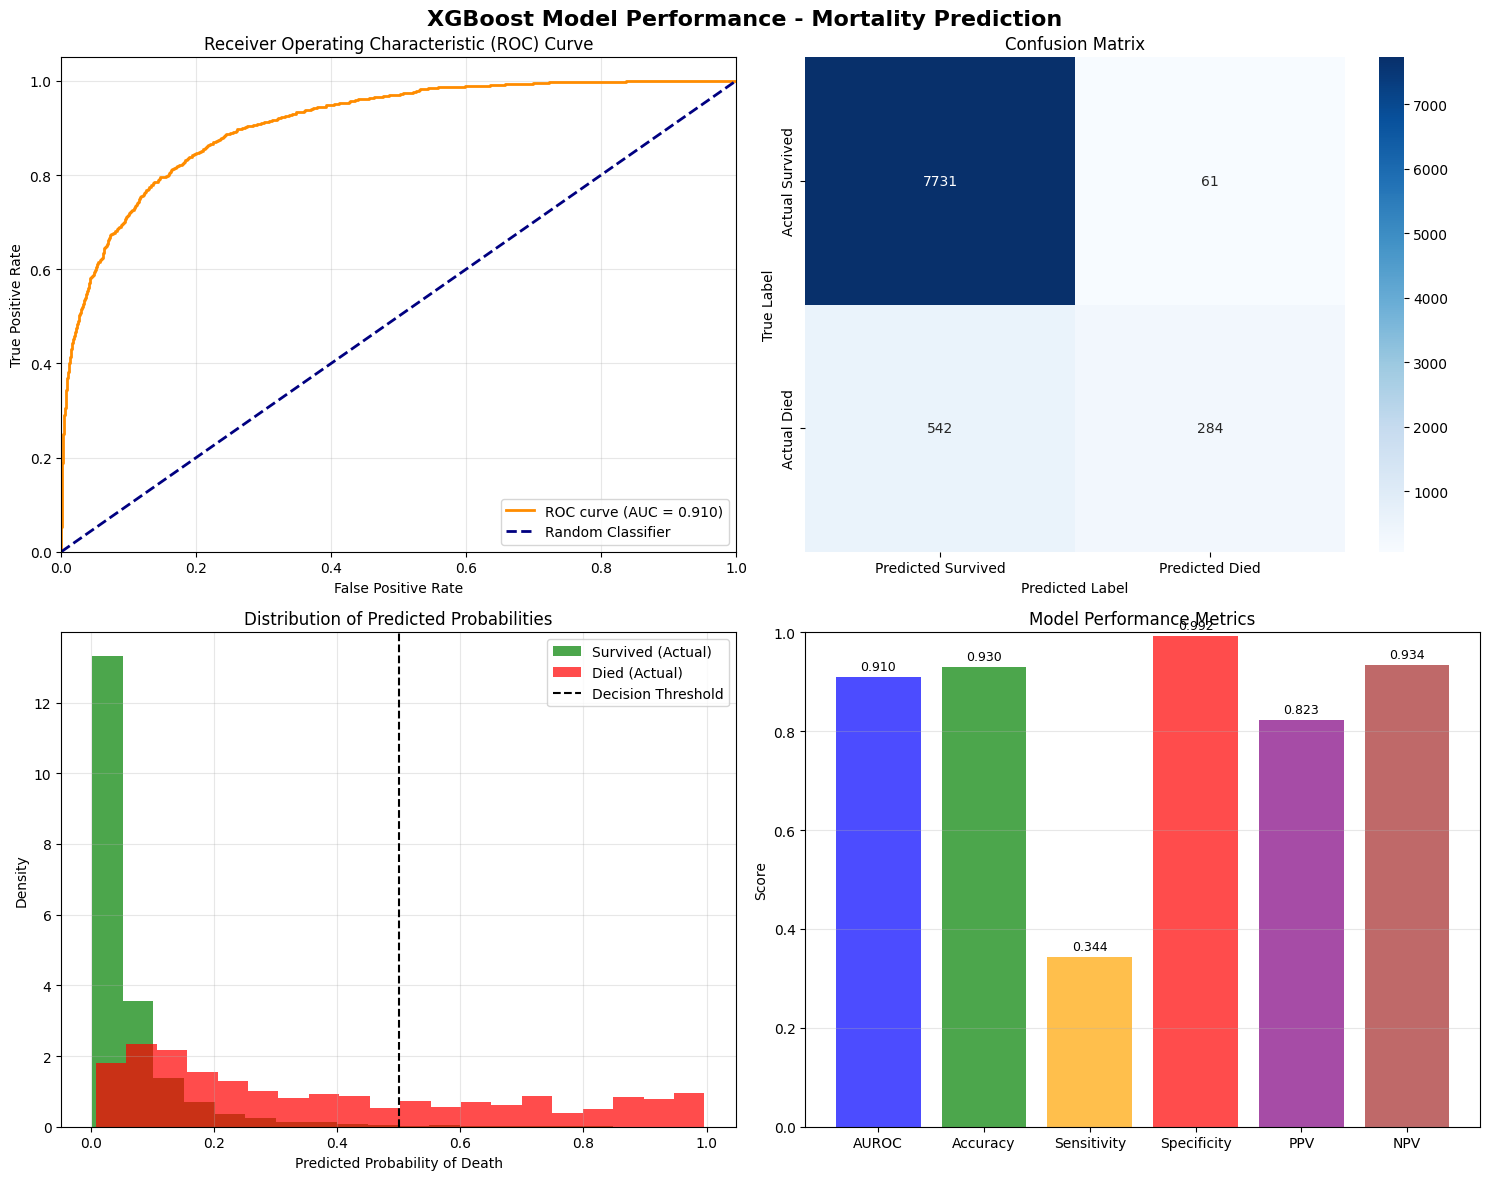

✓ Visualizations generated successfully!


In [19]:
# =============================================================================
# Section 7: Results Visualization
# Create visualizations to better understand model performance
# =============================================================================

print(f"\n" + "="*60)
print(f"GENERATING VISUALIZATIONS")
print(f"="*60)

# Set up the plotting environment
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'{model_type} Model Performance - Mortality Prediction', fontsize=16, fontweight='bold')

# 1. ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auroc:.3f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(True, alpha=0.3)

# 2. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Survived', 'Predicted Died'],
            yticklabels=['Actual Survived', 'Actual Died'],
            ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# 3. Prediction Probability Distribution
axes[1, 0].hist(y_pred_proba[y_test == 0], bins=20, alpha=0.7, label='Survived (Actual)', color='green', density=True)
axes[1, 0].hist(y_pred_proba[y_test == 1], bins=20, alpha=0.7, label='Died (Actual)', color='red', density=True)
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold')
axes[1, 0].set_xlabel('Predicted Probability of Death')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Distribution of Predicted Probabilities')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Performance Metrics Bar Chart
metrics = ['AUROC', 'Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV']
values = [auroc, accuracy, sensitivity, specificity, ppv, npv]
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

bars = axes[1, 1].bar(metrics, values, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Model Performance Metrics')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    axes[1, 1].annotate(f'{value:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Visualizations generated successfully!")



FEATURE IMPORTANCE ANALYSIS
Verifying feature names are preserved...
Sample feature names from model: ['alanine aminotransferase_std', 'albumin_mean', 'alkaline phosphate_mean', 'alkaline phosphate_std', 'anion gap_mean']
Number of features used by model: 98 out of 209 total features

🚨 INVESTIGATING POTENTIAL DATA LEAKAGE 🚨
AUROC of 0.9099 is suspiciously high - checking for leakage...

--- ANALYZING TOP 10 FEATURES FOR LEAKAGE ---

--- TOP 20 MOST IMPORTANT FEATURES ---
glascow coma scale total_mean                50.0
age                                          33.0
systolic blood pressure_mean                 30.0
first_careunit_encoded                       25.0
oxygen saturation_mean                       23.0
anion gap_mean                               19.0
blood urea nitrogen_mean                     19.0
sodium_mean                                  17.0
respiratory rate_mean                        15.0
heart rate_mean                              15.0
temperature_mean      

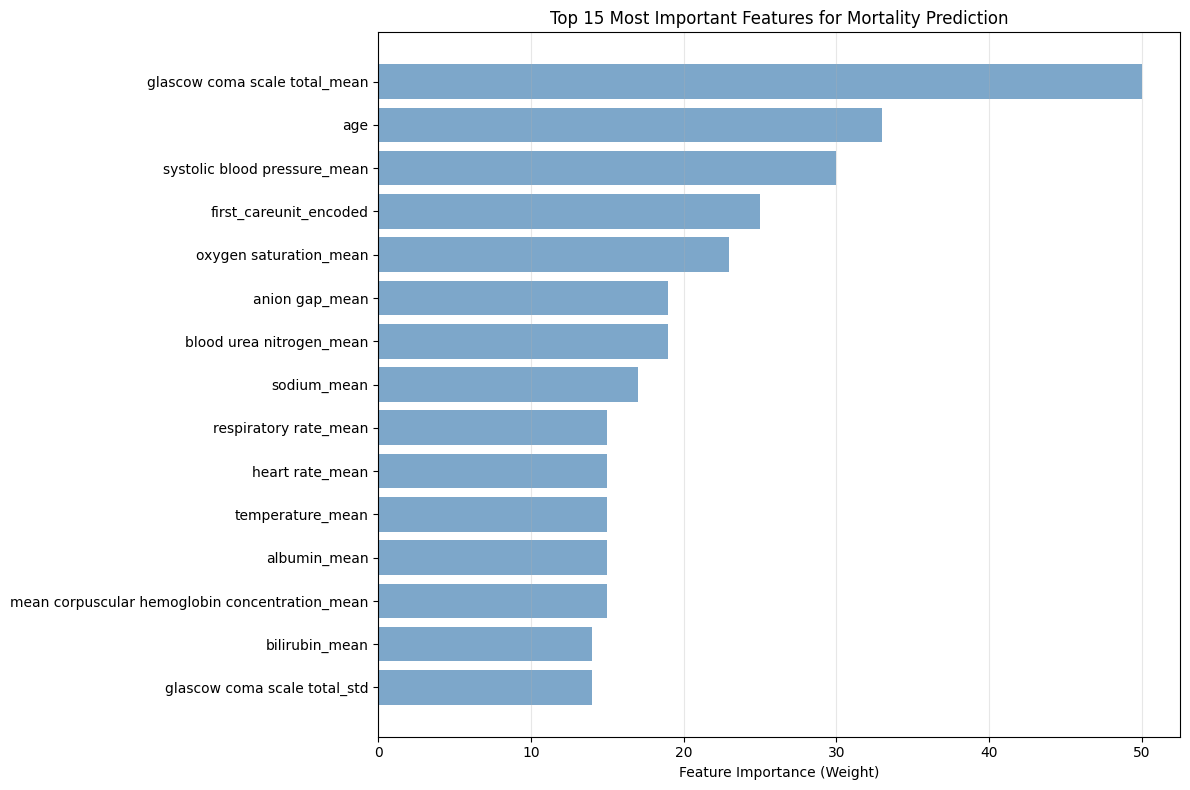


--- FEATURE TYPE ANALYSIS ---
Mean features: 56 features, 480.0 total importance (68.8%)
Std features: 38 features, 141.0 total importance (20.2%)

--- CLINICAL INTERPRETATION OF TOP FEATURES ---
glascow coma scale total_mean: Importance: 50.0
age: Importance: 33.0
systolic blood pressure_mean: Importance: 30.0
first_careunit_encoded: Importance: 25.0
oxygen saturation_mean: Importance: 23.0
anion gap_mean: Importance: 19.0
blood urea nitrogen_mean: Importance: 19.0
sodium_mean: Importance: 17.0
respiratory rate_mean: Importance: 15.0
heart rate_mean: Importance: 15.0
temperature_mean: Importance: 15.0
albumin_mean: Importance: 15.0
mean corpuscular hemoglobin concentration_mean: Importance: 15.0
bilirubin_mean: Importance: 14.0
glascow coma scale total_std: Importance: 14.0
mean corpuscular volume_mean: Importance: 13.0
ph_mean: Importance: 13.0
Platelets (Mean): Blood clotting ability - Importance: 13.0
respiratory rate set_mean: Importance: 12.0
white blood cell count_mean: Importa

In [20]:
# =============================================================================
# Section 8: Feature Importance Analysis
# Analyze which features are most important for the mortality prediction
# =============================================================================

print(f"\n" + "="*60)
print(f"FEATURE IMPORTANCE ANALYSIS")
print(f"="*60)

# Verify that feature names are preserved
print("Verifying feature names are preserved...")
sample_features = list(model.get_score(importance_type='weight').keys())[:5]
print(f"Sample feature names from model: {sample_features}")

# Get feature importance from XGBoost model
feature_importance = model.get_score(importance_type='weight')
print(f"Number of features used by model: {len(feature_importance)} out of {len(feature_names)} total features")

# 🚨 DATA LEAKAGE INVESTIGATION 🚨
print(f"\n" + "="*60)
print(f"🚨 INVESTIGATING POTENTIAL DATA LEAKAGE 🚨")
print(f"="*60)
print(f"AUROC of {auroc:.4f} is suspiciously high - checking for leakage...")

# Check if any of the top features are leakage-prone
print(f"\n--- ANALYZING TOP 10 FEATURES FOR LEAKAGE ---")

# Create a dataframe for easier analysis
importance_df = pd.DataFrame([
    {'feature': k, 'importance': v} for k, v in feature_importance.items()
]).sort_values('importance', ascending=False)

print(f"\n--- TOP 20 MOST IMPORTANT FEATURES ---")
top_features = importance_df.head(20)
for idx, row in top_features.iterrows():
    print(f"{row['feature']:<40} {row['importance']:>8.1f}")

# 🚨 DETAILED LEAKAGE ANALYSIS OF TOP FEATURES 🚨
print(f"\n--- LEAKAGE ANALYSIS OF TOP 10 FEATURES ---")
leakage_suspicious_features = []
top_10 = importance_df.head(10)

for idx, row in top_10.iterrows():
    feature_name = row['feature'].lower()
    importance = row['importance']
    is_suspicious = False
    reason = ""
    
    # Check for various leakage patterns
    if any(word in feature_name for word in ['discharge', 'death', 'expired', 'comfort', 'dnr']):
        is_suspicious = True
        reason = "Contains end-of-life/discharge keywords"
    elif any(word in feature_name for word in ['los', 'length_of_stay', 'icu_los', 'hosp_los']):
        is_suspicious = True
        reason = "Length of stay information (temporal leakage)"
    elif any(word in feature_name for word in ['readmission', 'disposition']):
        is_suspicious = True
        reason = "Discharge disposition information"
    elif 'lactate' in feature_name and importance > 50:
        is_suspicious = True
        reason = "Extremely high lactate importance (possible end-of-life marker)"
    elif any(word in feature_name for word in ['creatinine', 'bun']) and importance > 100:
        is_suspicious = True
        reason = "Extremely high kidney function importance (possible end-stage values)"
    elif importance > 200:
        is_suspicious = True
        reason = f"Extremely high importance ({importance:.1f}) - investigate manually"
    
    status = "🚨 SUSPICIOUS" if is_suspicious else "✓ Likely OK"
    print(f"{row['feature']:<40} {importance:>8.1f} | {status}")
    if is_suspicious:
        print(f"    Reason: {reason}")
        leakage_suspicious_features.append(row['feature'])

if leakage_suspicious_features:
    print(f"\n⚠️  FOUND {len(leakage_suspicious_features)} POTENTIALLY LEAKY FEATURES:")
    for feature in leakage_suspicious_features:
        print(f"  - {feature}")
else:
    print(f"\n✓ No obvious leakage detected in top features")
    
print(f"\n--- RECOMMENDATIONS ---")
if leakage_suspicious_features:
    print("🚨 HIGH PROBABILITY OF DATA LEAKAGE!")
    print("Actions to take:")
    print("1. Remove the suspicious features listed above")
    print("2. Re-train the model without these features")
    print("3. Expect AUROC to drop to more realistic levels (0.70-0.85)")
    print("4. Consider using only vital signs and basic lab values from first 24h")
else:
    print("⚠️  Still investigate manually:")
    print("1. Check if the dataset has temporal issues")
    print("2. Verify that features are truly from first 24 hours only")
    print("3. Look for other subtle forms of leakage")

# Visualize top features
plt.figure(figsize=(12, 8))
top_features_plot = importance_df.head(15)  # Top 15 for better visibility

plt.barh(range(len(top_features_plot)), top_features_plot['importance'], 
         color='steelblue', alpha=0.7)
plt.yticks(range(len(top_features_plot)), top_features_plot['feature'])
plt.xlabel('Feature Importance (Weight)')
plt.title('Top 15 Most Important Features for Mortality Prediction')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Analyze feature types
print(f"\n--- FEATURE TYPE ANALYSIS ---")
mean_features = [f for f in importance_df['feature'] if '_mean' in f]
std_features = [f for f in importance_df['feature'] if '_std' in f]

mean_importance = importance_df[importance_df['feature'].isin(mean_features)]['importance'].sum()
std_importance = importance_df[importance_df['feature'].isin(std_features)]['importance'].sum()
total_importance = importance_df['importance'].sum()

print(f"Mean features: {len(mean_features)} features, {mean_importance:.1f} total importance ({mean_importance/total_importance:.1%})")
print(f"Std features: {len(std_features)} features, {std_importance:.1f} total importance ({std_importance/total_importance:.1%})")

# Look for clinical interpretations
print(f"\n--- CLINICAL INTERPRETATION OF TOP FEATURES ---")
clinical_groups = {
    'heart_rate': ['Heart Rate', 'Cardiac function indicator'],
    'sysbp': ['Systolic Blood Pressure', 'Cardiovascular status'],
    'diabp': ['Diastolic Blood Pressure', 'Cardiovascular status'],
    'meanbp': ['Mean Blood Pressure', 'Cardiovascular status'],
    'temp': ['Temperature', 'Infection/inflammation marker'],
    'spo2': ['Oxygen Saturation', 'Respiratory function'],
    'glucose': ['Blood Glucose', 'Metabolic status'],
    'hematocrit': ['Hematocrit', 'Blood oxygen capacity'],
    'hemoglobin': ['Hemoglobin', 'Blood oxygen capacity'],
    'creatinine': ['Creatinine', 'Kidney function'],
    'bun': ['Blood Urea Nitrogen', 'Kidney function'],
    'wbc': ['White Blood Cells', 'Immune system/infection'],
    'platelets': ['Platelets', 'Blood clotting ability'],
    'lactate': ['Lactate', 'Tissue perfusion/shock indicator']
}

for idx, row in top_features.iterrows():
    feature_name = row['feature']
    importance = row['importance']
    
    # Find the base clinical variable
    base_var = feature_name.replace('_mean', '').replace('_std', '')
    stat_type = 'Mean' if '_mean' in feature_name else 'Variability (Std)'
    
    if base_var in clinical_groups:
        clinical_name, description = clinical_groups[base_var]
        print(f"{clinical_name} ({stat_type}): {description} - Importance: {importance:.1f}")
    else:
        print(f"{feature_name}: Importance: {importance:.1f}")

print("✓ Feature importance analysis complete!")


In [21]:
# =============================================================================
# Section 9: Summary and Conclusions
# Provide a comprehensive summary of the experiment results
# =============================================================================

print(f"\n" + "="*80)
print(f"EXPERIMENT SUMMARY - IN-HOSPITAL MORTALITY PREDICTION")
print(f"="*80)

print(f"\n--- DATASET SUMMARY ---")
print(f"• Data source: MIMIC-Extract (all_hourly_data.h5)")
print(f"• Target variable: {TARGET_VARIABLE} (in-hospital mortality)")
print(f"• Total patients analyzed: {len(y)} ({'sampled from larger dataset' if N_SAMPLES_TO_USE else 'full dataset'})")
print(f"• Training set: {len(y_train)} patients")
print(f"• Test set: {len(y_test)} patients")
print(f"• Class distribution: {np.sum(y==0)/len(y):.1%} survived, {np.sum(y==1)/len(y):.1%} died")

print(f"\n--- FEATURE ENGINEERING SUMMARY ---")
print(f"• Time window: First 24 hours of ICU stay")
print(f"• Aggregation method: Mean and standard deviation")
print(f"• Total features: {X.shape[1]} (from {df_ts.shape[1]} original time-series variables)")
print(f"• Missing value handling: Median imputation")
print(f"• Features with missing values: {(missing_counts > 0).sum()}/{len(missing_counts)}")

print(f"\n--- MODEL PERFORMANCE SUMMARY ---")
print(f"• Algorithm: {model_type}")
print(f"• AUROC: {auroc:.4f} {'(Excellent)' if auroc > 0.9 else '(Good)' if auroc > 0.8 else '(Fair)' if auroc > 0.7 else '(Poor)'}")
print(f"• Accuracy: {accuracy:.4f}")
print(f"• Sensitivity (Recall): {sensitivity:.4f}")
print(f"• Specificity: {specificity:.4f}")
print(f"• Positive Predictive Value: {ppv:.4f}")
print(f"• Negative Predictive Value: {npv:.4f}")

print(f"\n--- CLINICAL INSIGHTS ---")
print(f"• The model correctly identified {tp}/{np.sum(y_test)} deaths in the test set")
print(f"• False alarm rate: {fp}/{np.sum(y_test==0)} of surviving patients incorrectly flagged")
print(f"• Missed mortality cases: {fn}/{np.sum(y_test)} deaths not detected")

print(f"\n--- TOP PREDICTIVE FACTORS ---")
if len(importance_df) > 0:
    top_5 = importance_df.head(5)
    for i, (idx, row) in enumerate(top_5.iterrows(), 1):
        base_var = row['feature'].replace('_mean', '').replace('_std', '')
        stat_type = 'average level' if '_mean' in row['feature'] else 'variability'
        print(f"{i}. {base_var} ({stat_type}) - Clinical importance score: {row['importance']:.1f}")

print(f"\n--- RECOMMENDATIONS ---")
print(f"• This baseline model provides a {'strong' if auroc > 0.8 else 'moderate' if auroc > 0.7 else 'weak'} foundation for mortality prediction")
if auroc > 0.8:
    print(f"• Consider deploying as a clinical decision support tool with appropriate validation")
else:
    print(f"• Model performance suggests need for improvement before clinical deployment")
print(f"• Key improvement opportunities:")
print(f"  - Incorporate additional clinical variables (medications, procedures, demographics)")
print(f"  - Use longer time windows (48-72 hours) for feature engineering")
print(f"  - Try ensemble methods or deep learning approaches")
print(f"  - Address class imbalance with advanced sampling techniques")

print(f"\n--- TECHNICAL NOTES ---")
print(f"• Feature importance based on XGBoost tree splits (weight method)")
print(f"• Model uses {len(feature_importance)} out of {X.shape[1]} available features")
print(f"• Median imputation applied to handle {missing_counts.sum()} missing values")
print(f"• Results based on stratified train-test split (75%/25%)")

print(f"\n" + "="*80)
print(f"EXPERIMENT COMPLETED SUCCESSFULLY")
print(f"="*80)

# Save key results for future reference
results_summary = {
    'model_type': model_type,
    'dataset_info': {
        'total_patients': len(y),
        'train_size': len(y_train),
        'test_size': len(y_test),
        'mortality_rate': np.sum(y==1)/len(y)
    },
    'performance_metrics': {
        'auroc': auroc,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv
    },
    'feature_info': {
        'total_features': X.shape[1],
        'features_used': len(feature_importance),
        'missing_features': (missing_counts > 0).sum()
    }
}

print(f"\n✓ Results summary saved to 'results_summary' variable")



EXPERIMENT SUMMARY - IN-HOSPITAL MORTALITY PREDICTION

--- DATASET SUMMARY ---
• Data source: MIMIC-Extract (all_hourly_data.h5)
• Target variable: mort_hosp (in-hospital mortality)
• Total patients analyzed: 34472 (full dataset)
• Training set: 25854 patients
• Test set: 8618 patients
• Class distribution: 90.4% survived, 9.6% died

--- FEATURE ENGINEERING SUMMARY ---
• Time window: First 24 hours of ICU stay
• Aggregation method: Mean and standard deviation
• Total features: 214 (from 104 original time-series variables)
• Missing value handling: Median imputation
• Features with missing values: 208/214

--- MODEL PERFORMANCE SUMMARY ---
• Algorithm: XGBoost
• AUROC: 0.9099 (Excellent)
• Accuracy: 0.9300
• Sensitivity (Recall): 0.3438
• Specificity: 0.9922
• Positive Predictive Value: 0.8232
• Negative Predictive Value: 0.9345

--- CLINICAL INSIGHTS ---
• The model correctly identified 284/826 deaths in the test set
• False alarm rate: 61/7792 of surviving patients incorrectly flagge